In [1]:
1+1

2

In [2]:
import numpy as np
import pandas as pd


In [ ]:
# Nomenclature

In [ ]:
data (X, y) --> training (algorithms) --> model 

X --> model --> y 

In [ ]:
# data (X, y) 

# X - rows x columns (Input)

# rows == instance, experience, examples, memories, data point, sample, 
# columns == features, attributes, characterstics, properties, qualities, 

# y - output, label, ... 

In [ ]:
X - capitals -> table / Matrix / dataframe 
y -> small case -> vector/list/array 


In [ ]:
# multilabel system
Y - image. 


In [ ]:
for x = 3, y was 5, and for x = 10, y was 12. 
Build a linear model to convert x to y. 

X 
[
    [3],
    [10]
 ]

y = [5, 12]


In [ ]:
# (x1, x2) --> y 

[1,2]-> 4
[4, 5] -> 10
[3, 0] -> 12

X = 
[
    [1, 2],
    [4, 5],
    [3, 0]
]

y = [4, 10, 12]

In [5]:
x_raw = np.array([3, 10])

X = x_raw.reshape(-1, 1)
X

array([[ 3],
       [10]])

In [ ]:
# linear simple model
X 
[
    [3],
    [10]
 ]

y = [5, 12]

def fit(X, y): # training
    # m, c
    # y = mx + c
    m = 
    c = 
    model = (m, c)
    return model

def predict(model, X): # inference
    m, c = model
    y_p = ...
    return y_p

model = fit(X, y)
y_predict = predict(model, X)
print(y_predict)

[[ 5.]
 [12.]]


In [ ]:
rom sklearn.linear_model import LinearRegression
import numpy as np

# Training data
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5]
])

y = np.array([2, 4, 6, 8, 10])

# Create model
model = LinearRegression()

# Learn from data
model.fit(X, y)

# Predict on new data
X_test = np.array([
    [6],
    [7],
    [8]
])

predictions = model.predict(X_test)

print(predictions)

In [ ]:
# DecisionTreeClassifier
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, Y)
clf.predict([[2., 2.]])


In [ ]:
# https://chatgpt.com/share/6a49e185-abf0-83ea-97d6-7edfebbbb8e1
# All models from sklearn have .fit() and predict()

In [ ]:
# Example: Use KNN to build fit/predict

In [ ]:
# Supervised Machine Learning has X and y.
# X ---> Model --> y

# Unsupervised Machine Learning
You are given 1000s of photos.

# 1. Compressing the data / Dimensionality Reduction

# 2.0 Clustering (KMean, ..)

# 2.1 Heirarchical clustering
2. You have 1000s of the car models
Each car is a list of features: How big is cylinder, how many cylinders, Diesel, Petrol, ...
Creating 4 clusters such that cars in each cluster is more closer to each other than the cars in other cluster.
Can I find the distance between two cars? Eucledian distance

Darvin did Aglomrative CLustering.

Q: 
1. Downloaded information about 5000 apps from android app store.
2. For each app, generated embeddings
3. Kmeans clusterings (4 groups) recursively as long > 10 apps.
4. Labeled each group - frequency computation and picked most common word.

# You are given handwritten digits. 100,000 
# How would you group them such that each group would endup with similar digit.

# 3.0 Anomaly Detection - fraud detection etc.
- Create two groups, 

# Converting Text into EMbeddings using LLM


In [ ]:
# Is product recommendations an unsupervised learning?

In [13]:
# https://chatgpt.com/c/6a531c93-2510-83ea-bd22-53e42222f58c

Downloading/loading MNIST...
Original data shape: (70000, 784)
Labels shape: (70000,)

Applying PCA...
PCA data shape: (70000, 50)
Variance retained: 82.54%

Training K-Means...
Training completed in 2.61 seconds

Cluster-to-digit mapping:
Cluster 0 -> Digit 0
Cluster 1 -> Digit 1
Cluster 2 -> Digit 8
Cluster 3 -> Digit 7
Cluster 4 -> Digit 5
Cluster 5 -> Digit 9
Cluster 6 -> Digit 3
Cluster 7 -> Digit 6
Cluster 8 -> Digit 2
Cluster 9 -> Digit 4

Clustering metrics:
                       Metric         Value
                      Inertia  3.086592e+06
             Silhouette score -2.537938e-02
                  Homogeneity  4.247802e-01
                 Completeness  4.319280e-01
                    V-measure  4.283243e-01
          Adjusted Rand Index  2.957777e-01
  Adjusted Mutual Information  4.281793e-01
Normalized Mutual Information  4.283243e-01
                       Purity  4.994286e-01
   Hungarian-matched accuracy  4.902286e-01
     Training time in seconds  2.605976e+00



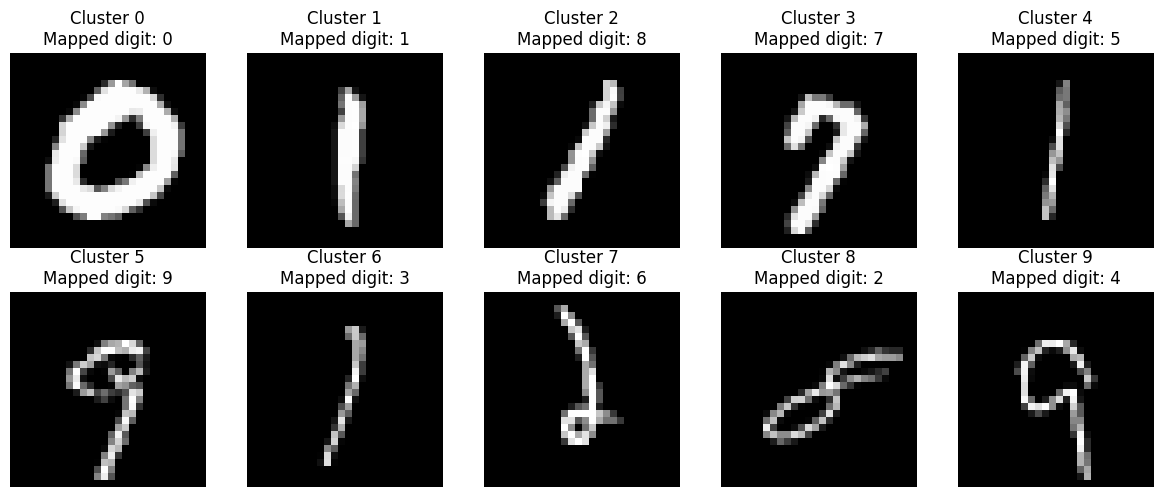

In [12]:
# Install dependencies if necessary:
# pip install numpy pandas matplotlib scikit-learn scipy

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    confusion_matrix,
    homogeneity_completeness_v_measure,
    normalized_mutual_info_score,
    silhouette_score,
)


# ---------------------------------------------------------
# 1. Load MNIST
# ---------------------------------------------------------

print("Downloading/loading MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto",
)

X = mnist.data.astype(np.float32)
y_true = mnist.target.astype(np.int64)

print("Original data shape:", X.shape)
print("Labels shape:", y_true.shape)


# ---------------------------------------------------------
# 2. Normalize pixel values
# ---------------------------------------------------------

# MNIST pixels originally range from 0 to 255.
X = X / 255.0


# ---------------------------------------------------------
# 3. Reduce dimensionality using PCA
# ---------------------------------------------------------

# K-Means can work directly on all 784 pixels, but PCA makes
# the experiment faster and often gives cleaner clusters.

pca = PCA(
    n_components=50,
    whiten=True,
    random_state=42,
)

print("\nApplying PCA...")
X_pca = pca.fit_transform(X)

print("PCA data shape:", X_pca.shape)
print(
    "Variance retained:",
    f"{pca.explained_variance_ratio_.sum():.2%}",
)


# ---------------------------------------------------------
# 4. Perform K-Means clustering
# ---------------------------------------------------------

kmeans = KMeans(
    n_clusters=10,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42,
    verbose=0,
)

print("\nTraining K-Means...")

start_time = time.time()
cluster_labels = kmeans.fit_predict(X_pca)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")


# ---------------------------------------------------------
# 5. Metrics that do not require mapping cluster IDs
# ---------------------------------------------------------

homogeneity, completeness, v_measure = (
    homogeneity_completeness_v_measure(
        y_true,
        cluster_labels,
    )
)

ari = adjusted_rand_score(y_true, cluster_labels)
ami = adjusted_mutual_info_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

# Computing silhouette score on all 70,000 images is expensive.
# Therefore, estimate it from a reproducible sample.
silhouette = silhouette_score(
    X_pca,
    cluster_labels,
    sample_size=10_000,
    random_state=42,
)


# ---------------------------------------------------------
# 6. Purity score
# ---------------------------------------------------------

def calculate_purity(
    true_labels: np.ndarray,
    predicted_clusters: np.ndarray,
) -> float:
    """
    Calculate clustering purity.

    Purity assigns each cluster to its most common true class.
    """
    matrix = confusion_matrix(true_labels, predicted_clusters)
    return np.sum(np.max(matrix, axis=0)) / np.sum(matrix)


purity = calculate_purity(y_true, cluster_labels)


# ---------------------------------------------------------
# 7. Map clusters to digits with Hungarian matching
# ---------------------------------------------------------

def map_clusters_to_digits(
    true_labels: np.ndarray,
    predicted_clusters: np.ndarray,
) -> tuple[np.ndarray, dict[int, int], float]:
    """
    Match cluster IDs to true digit labels using the Hungarian algorithm.

    Cluster 0 does not necessarily represent digit 0, so direct
    classification accuracy cannot be calculated before matching.
    """
    matrix = confusion_matrix(
        true_labels,
        predicted_clusters,
        labels=np.arange(10),
    )

    # Find the assignment that maximizes correctly matched samples.
    true_digit_indices, cluster_indices = linear_sum_assignment(-matrix)

    cluster_to_digit = {
        cluster: digit
        for digit, cluster in zip(true_digit_indices, cluster_indices)
    }

    mapped_predictions = np.array(
        [cluster_to_digit[cluster] for cluster in predicted_clusters]
    )

    accuracy = np.mean(mapped_predictions == true_labels)

    return mapped_predictions, cluster_to_digit, accuracy


mapped_predictions, cluster_to_digit, cluster_accuracy = (
    map_clusters_to_digits(
        y_true,
        cluster_labels,
    )
)


# ---------------------------------------------------------
# 8. Collect and print metrics
# ---------------------------------------------------------

metrics = {
    "Inertia": kmeans.inertia_,
    "Silhouette score": silhouette,
    "Homogeneity": homogeneity,
    "Completeness": completeness,
    "V-measure": v_measure,
    "Adjusted Rand Index": ari,
    "Adjusted Mutual Information": ami,
    "Normalized Mutual Information": nmi,
    "Purity": purity,
    "Hungarian-matched accuracy": cluster_accuracy,
    "Training time in seconds": training_time,
}

metrics_df = pd.DataFrame(
    {
        "Metric": metrics.keys(),
        "Value": metrics.values(),
    }
)

print("\nCluster-to-digit mapping:")
for cluster, digit in sorted(cluster_to_digit.items()):
    print(f"Cluster {cluster} -> Digit {digit}")

print("\nClustering metrics:")
print(metrics_df.to_string(index=False))


# ---------------------------------------------------------
# 9. Show cluster composition
# ---------------------------------------------------------

composition = pd.crosstab(
    pd.Series(cluster_labels, name="Cluster"),
    pd.Series(y_true, name="True digit"),
)

print("\nCluster composition:")
print(composition)


# ---------------------------------------------------------
# 10. Visualize images closest to cluster centers
# ---------------------------------------------------------

# Distance of every image from every cluster center
distances = kmeans.transform(X_pca)

# Find the image closest to each cluster center
representative_indices = np.argmin(distances, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for cluster_id, axis in enumerate(axes.flat):
    image_index = representative_indices[cluster_id]
    predicted_digit = cluster_to_digit[cluster_id]

    axis.imshow(
        X[image_index].reshape(28, 28),
        cmap="gray",
    )

    axis.set_title(
        f"Cluster {cluster_id}\n"
        f"Mapped digit: {predicted_digit}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()